# Time-Zero Bias in EHR Studies: A Comprehensive Tutorial

**Learning Objectives:**
1. Distinguish multiple temporal reference points in EHR reality
2. Apply diagnostic tools to detect time-zero problems
3. Understand how different fixes shift the estimand
4. Recognize fundamental limitations when onset is unobserved

**Key Message:** Design choices in observational studies are constrained by data availability, and transparent reporting of these constraints is essential for valid causal inference.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import median_survival_times
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

/Users/yanfeiwang/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1. Simulation: Four Distinct Time Points

We simulate a cohort with realistic EHR temporal structure:

- **T_onset** (unobserved): Biological disease onset
- **T_encounter** (observed): First healthcare encounter
- **T_decision** (observed): Treatment decision made
- **T_documentation** (observed): Prescription recorded in EHR

**Key features:**
- Onset-to-encounter delay correlates with severity
- Treatment assignment depends on severity
- Outcome risk increases with severity
- Documentation lags decision (administrative delay)

In [3]:
def simulate_ehr_cohort(n=1000, seed=42):
    """
    Simulate EHR cohort with four distinct time points.
    
    Returns:
        DataFrame with columns:
        - patient_id
        - severity (continuous, higher = worse)
        - t_onset (biological onset, day 0)
        - t_encounter (first clinical encounter)
        - t_decision (treatment decision)
        - t_documentation (prescription recorded)
        - treated (binary)
        - t_outcome (event time from onset)
        - event (binary outcome indicator)
        - baseline_lab (covariate measured at encounter)
        - followup_lab (covariate measured post-decision, potential leakage)
    """
    np.random.seed(seed)
    
    # Baseline severity (unobserved confounder)
    severity = np.random.gamma(shape=2, scale=1, size=n)
    
    # T_onset = 0 (reference point)
    t_onset = np.zeros(n)
    
    # T_encounter: sicker patients delay care longer
    # Mean delay increases with severity
    delay_mean = 10 + 15 * (severity / severity.max())
    t_encounter = t_onset + np.random.exponential(delay_mean)
    
    # T_decision: occurs 1-7 days after encounter
    t_decision = t_encounter + np.random.uniform(1, 7, size=n)
    
    # Treatment assignment (depends on severity, measured at encounter)
    treatment_prob = 1 / (1 + np.exp(-(-1 + 0.8 * severity)))
    treated = np.random.binomial(1, treatment_prob)
    
    # T_documentation: administrative lag after decision
    # Only for treated patients; controls have no documentation
    doc_lag = np.random.lognormal(mean=0.5, sigma=0.8, size=n)
    t_documentation = np.where(treated == 1, t_decision + doc_lag, np.nan)
    
    # Outcome (time from onset)
    # Higher severity = higher hazard
    # Treatment reduces hazard (true effect: HR = 0.6)
    baseline_hazard = 0.02
    hazard = baseline_hazard * np.exp(0.5 * severity - 0.51 * treated)  # -0.51 ≈ log(0.6)
    t_outcome_from_onset = np.random.exponential(1 / hazard)
    
    # Administrative censoring at 365 days from onset
    admin_censor = 365
    event = (t_outcome_from_onset < admin_censor).astype(int)
    t_outcome = np.minimum(t_outcome_from_onset, admin_censor)
    
    # Baseline covariate (measured at encounter)
    baseline_lab = 10 + 2 * severity + np.random.normal(0, 1, n)
    
    # Follow-up lab (measured post-decision, potential leakage)
    # Measured at decision + random delay
    followup_lab = 10 + 2 * severity + 3 * treated + np.random.normal(0, 1, n)
    
    df = pd.DataFrame({
        'patient_id': range(n),
        'severity': severity,
        't_onset': t_onset,
        't_encounter': t_encounter,
        't_decision': t_decision,
        't_documentation': t_documentation,
        'treated': treated,
        't_outcome': t_outcome,
        'event': event,
        'baseline_lab': baseline_lab,
        'followup_lab': followup_lab
    })
    
    return df

# Generate cohort
df = simulate_ehr_cohort(n=1000)
print(f"Cohort size: {len(df)}")
print(f"Treatment rate: {df['treated'].mean():.1%}")
print(f"Event rate: {df['event'].mean():.1%}")
df.head()

Cohort size: 1000
Treatment rate: 61.0%
Event rate: 100.0%


,patient_id,severity,t_onset,t_encounter,t_decision,t_documentation,treated,t_outcome,event,baseline_lab,followup_lab
0,0,2.393679,0.0,9.611969,16.022613,18.082557,1,2.057014,1,15.234340,19.136538
1,1,1.494465,0.0,2.811155,5.031991,NaN,0,50.465475,1,12.350344,13.013361
2,2,1.382284,0.0,11.948672,13.350513,NaN,0,2.031039,1,14.417877,13.085565
3,3,1.382302,0.0,4.171786,10.435889,11.468483,1,51.181225,1,13.387692,16.766841
4,4,4.649714,0.0,4.396515,7.732945,8.857056,1,20.571041,1,19.539287,23.859684


### 1.1 Swimming Lane Plot: Visualizing the Four Time Points

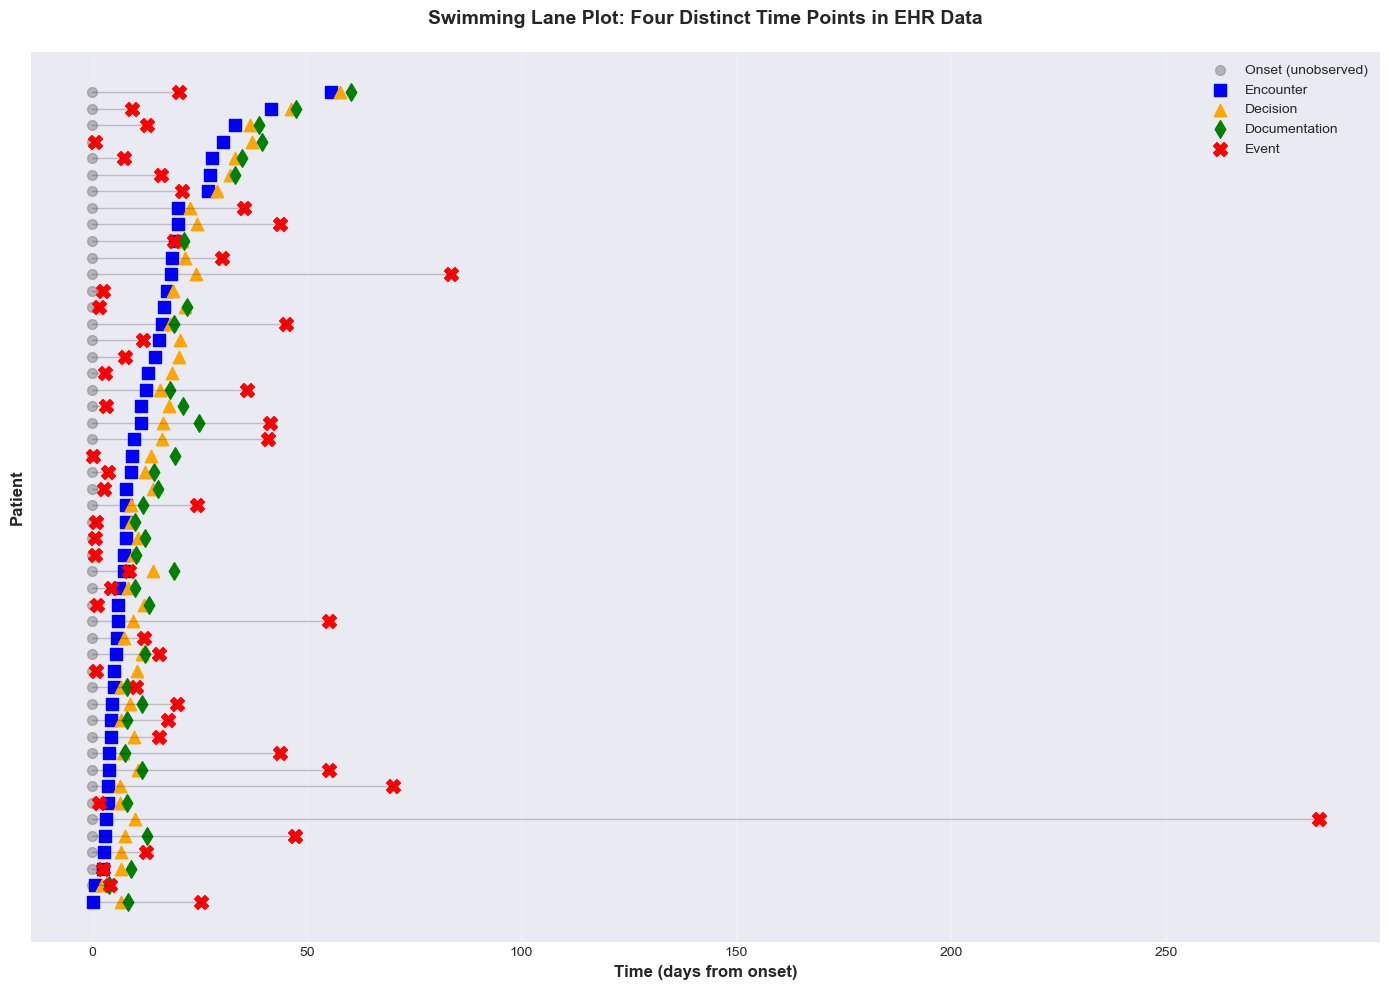

In [5]:
def plot_swimming_lanes(df, n_display=50):
    """
    Create swimming lane plot showing temporal sequence for each patient.
    """
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Sample patients for display
    display_df = df.sample(n=min(n_display, len(df)), random_state=42).sort_values('t_encounter')
    
    for idx, (i, row) in enumerate(display_df.iterrows()):
        y_pos = idx
        
        # Timeline from onset to outcome
        ax.plot([row['t_onset'], row['t_outcome']], [y_pos, y_pos], 
                'k-', alpha=0.2, linewidth=1)
        
        # Mark onset (unobserved)
        ax.scatter(row['t_onset'], y_pos, c='gray', s=50, marker='o', 
                  alpha=0.5, label='Onset (unobserved)' if idx == 0 else '')
        
        # Mark encounter
        ax.scatter(row['t_encounter'], y_pos, c='blue', s=80, marker='s', 
                  label='Encounter' if idx == 0 else '')
        
        # Mark decision
        ax.scatter(row['t_decision'], y_pos, c='orange', s=80, marker='^', 
                  label='Decision' if idx == 0 else '')
        
        # Mark documentation (only for treated)
        if row['treated'] == 1 and not np.isnan(row['t_documentation']):
            ax.scatter(row['t_documentation'], y_pos, c='green', s=80, marker='d', 
                      label='Documentation' if idx == 0 else '')
        
        # Mark outcome
        outcome_marker = 'X' if row['event'] == 1 else 'o'
        outcome_color = 'red' if row['event'] == 1 else 'lightgray'
        ax.scatter(row['t_outcome'], y_pos, c=outcome_color, s=100, marker=outcome_marker,
                  label='Event' if (idx == 0 and row['event'] == 1) else 
                        ('Censored' if (idx == 0 and row['event'] == 0) else ''))
    
    ax.set_xlabel('Time (days from onset)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Patient', fontsize=12, fontweight='bold')
    ax.set_title('Swimming Lane Plot: Four Distinct Time Points in EHR Data', 
                fontsize=14, fontweight='bold', pad=20)
    
    # Clean up legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=10)
    
    ax.set_yticks([])
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    return fig

fig = plot_swimming_lanes(df, n_display=50)
plt.show()

### 1.2 Demonstrating Time-Zero Choices and Their Consequences

We now compare three different time-zero choices:

1. **Naive (Encounter-anchored)**: Time zero = first encounter, treatment assigned if documented anytime
2. **Decision-anchored**: Time zero = treatment decision
3. **Truth (Onset-aligned)**: Time zero = biological onset (unobserved, for reference)

**Key issue:** Anchoring at encounter introduces **immortal time** between encounter and documentation.

In [7]:
def create_analysis_datasets(df):
    """
    Create three datasets with different time-zero definitions.
    """
    datasets = {}
    
    # 1. NAIVE: Anchor at encounter
    df_naive = df.copy()
    df_naive['time'] = df_naive['t_outcome'] - df_naive['t_encounter']
    df_naive['time'] = df_naive['time'].clip(lower=0.01)  # Avoid zero time
    # Exclude patients with outcome before encounter
    df_naive = df_naive[df_naive['time'] > 0]
    datasets['Naive (Encounter)'] = df_naive
    
    # 2. DECISION-ANCHORED: Anchor at decision time
    df_decision = df.copy()
    df_decision['time'] = df_decision['t_outcome'] - df_decision['t_decision']
    df_decision['time'] = df_decision['time'].clip(lower=0.01)
    # Exclude patients with outcome before decision
    df_decision = df_decision[df_decision['time'] > 0]
    datasets['Decision-anchored'] = df_decision
    
    # 3. TRUTH: Anchor at onset (unobserved in practice)
    df_truth = df.copy()
    df_truth['time'] = df_truth['t_outcome'] - df_truth['t_onset']
    datasets['Truth (Onset)'] = df_truth
    
    return datasets

datasets = create_analysis_datasets(df)

# Print sample sizes
for name, data in datasets.items():
    print(f"{name}: n={len(data)}, treated={data['treated'].sum()}, events={data['event'].sum()}")

Naive (Encounter): n=1000, treated=610, events=1000
Decision-anchored: n=1000, treated=610, events=1000
Truth (Onset): n=1000, treated=610, events=1000


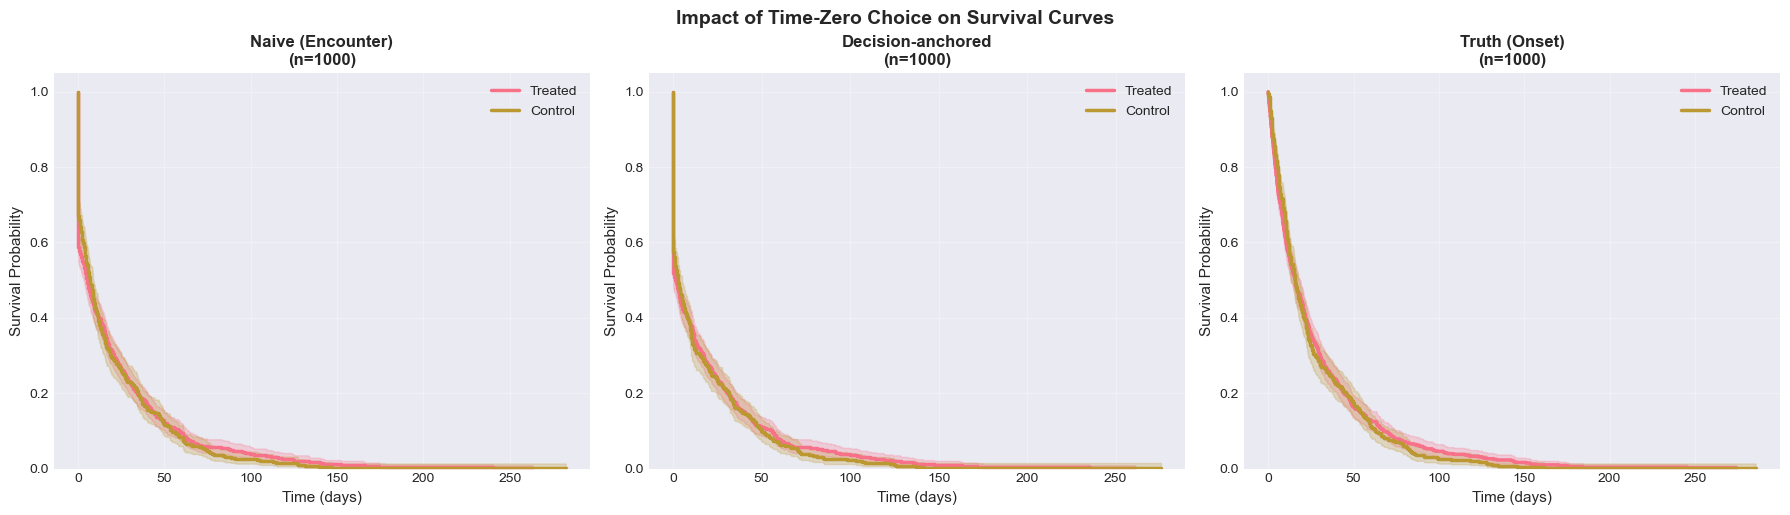


Median Survival Times:
         Approach    N Median Survival Treated Median Survival Control
Naive (Encounter) 1000                     5.1                     6.7
Decision-anchored 1000                     1.3                     2.9
    Truth (Onset) 1000                    15.9                    15.7


In [9]:
def plot_km_comparison(datasets):
    """
    Plot Kaplan-Meier curves for different time-zero choices.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    results_summary = []
    
    for idx, (name, data) in enumerate(datasets.items()):
        ax = axes[idx]
        
        # Fit KM for treated and control
        kmf_treated = KaplanMeierFitter()
        kmf_control = KaplanMeierFitter()
        
        treated_data = data[data['treated'] == 1]
        control_data = data[data['treated'] == 0]
        
        kmf_treated.fit(treated_data['time'], treated_data['event'], label='Treated')
        kmf_control.fit(control_data['time'], control_data['event'], label='Control')
        
        kmf_treated.plot_survival_function(ax=ax, ci_show=True, linewidth=2.5)
        kmf_control.plot_survival_function(ax=ax, ci_show=True, linewidth=2.5)
        
        ax.set_title(f'{name}\n(n={len(data)})', fontsize=12, fontweight='bold')
        ax.set_xlabel('Time (days)', fontsize=11)
        ax.set_ylabel('Survival Probability', fontsize=11)
        ax.set_ylim([0, 1.05])
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Calculate median survival times
        median_treated = kmf_treated.median_survival_time_
        median_control = kmf_control.median_survival_time_
        
        results_summary.append({
            'Approach': name,
            'N': len(data),
            'Median Survival Treated': f"{median_treated:.1f}",
            'Median Survival Control': f"{median_control:.1f}"
        })
    
    plt.tight_layout()
    plt.suptitle('Impact of Time-Zero Choice on Survival Curves', 
                fontsize=14, fontweight='bold', y=1.02)
    
    return fig, pd.DataFrame(results_summary)

fig, summary = plot_km_comparison(datasets)
plt.show()
print("\nMedian Survival Times:")
print(summary.to_string(index=False))

### 1.3 Immortal Time Visualization

Show how the naive approach creates **immortal time** between encounter and documentation.

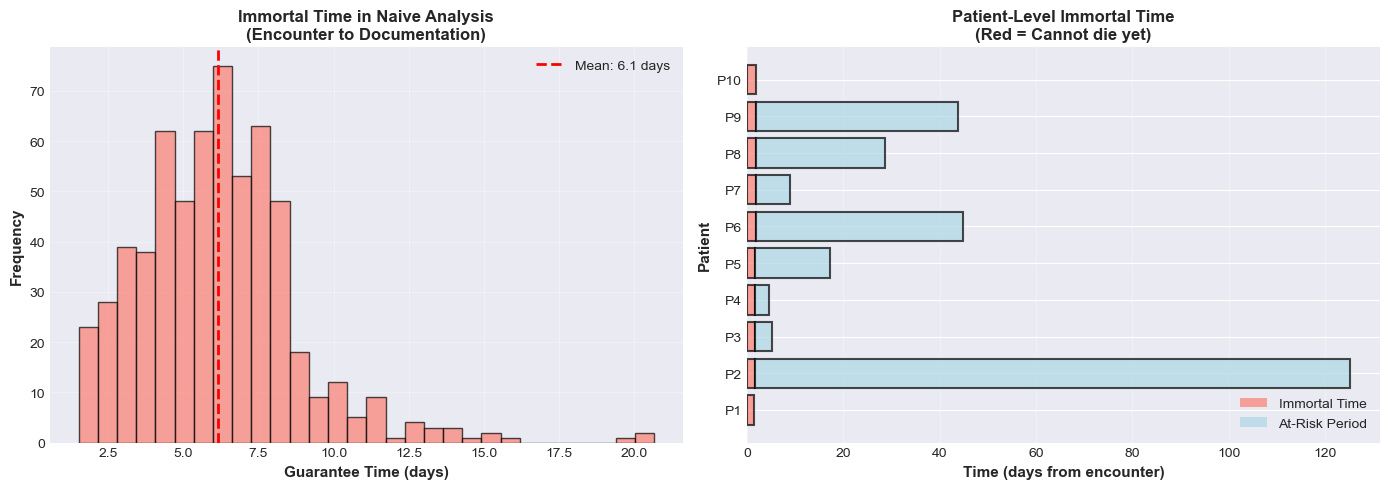


Immortal Time Summary (Treated Patients):
  Mean: 6.1 days
  Median: 6.0 days
  Range: [1.5, 20.7] days


In [11]:
def plot_immortal_time(df):
    """
    Visualize immortal time in naive analysis.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left panel: Histogram of guarantee time for treated patients
    treated_df = df[df['treated'] == 1].copy()
    treated_df['guarantee_time'] = treated_df['t_documentation'] - treated_df['t_encounter']
    
    axes[0].hist(treated_df['guarantee_time'], bins=30, color='salmon', alpha=0.7, edgecolor='black')
    axes[0].axvline(treated_df['guarantee_time'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {treated_df['guarantee_time'].mean():.1f} days")
    axes[0].set_xlabel('Guarantee Time (days)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
    axes[0].set_title('Immortal Time in Naive Analysis\n(Encounter to Documentation)', 
                     fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Right panel: Illustration with sample patients
    sample_patients = treated_df.nsmallest(10, 'guarantee_time')
    
    for idx, (i, row) in enumerate(sample_patients.iterrows()):
        y = idx
        # Encounter to documentation (immortal period)
        axes[1].barh(y, row['guarantee_time'], left=0, height=0.8, 
                    color='salmon', alpha=0.7, edgecolor='black', linewidth=1.5)
        # Documentation to outcome
        time_post_doc = (row['t_outcome'] - row['t_documentation'])
        if time_post_doc > 0:
            axes[1].barh(y, time_post_doc, left=row['guarantee_time'], 
                        height=0.8, color='lightblue', alpha=0.7, edgecolor='black', linewidth=1.5)
    
    axes[1].set_xlabel('Time (days from encounter)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Patient', fontsize=11, fontweight='bold')
    axes[1].set_title('Patient-Level Immortal Time\n(Red = Cannot die yet)', 
                     fontsize=12, fontweight='bold')
    axes[1].set_yticks(range(len(sample_patients)))
    axes[1].set_yticklabels([f"P{i+1}" for i in range(len(sample_patients))])
    axes[1].grid(True, alpha=0.3, axis='x')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='salmon', alpha=0.7, label='Immortal Time'),
                      Patch(facecolor='lightblue', alpha=0.7, label='At-Risk Period')]
    axes[1].legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    return fig

fig = plot_immortal_time(df)
plt.show()

# Summary statistics
treated_df = df[df['treated'] == 1]
guarantee_time = treated_df['t_documentation'] - treated_df['t_encounter']
print(f"\nImmortal Time Summary (Treated Patients):")
print(f"  Mean: {guarantee_time.mean():.1f} days")
print(f"  Median: {guarantee_time.median():.1f} days")
print(f"  Range: [{guarantee_time.min():.1f}, {guarantee_time.max():.1f}] days")

## 2. Time-Zero Diagnostics: A Practical Checklist

Before conducting any analysis, we should run these diagnostic checks to detect time-zero problems.

In [13]:
def run_time_zero_diagnostics(df, verbose=True):
    """
    Comprehensive time-zero diagnostic suite.
    
    Returns:
        Dictionary of diagnostic results
    """
    diagnostics = {}
    
    # === DIAGNOSTIC 1: Treatment-outcome temporal violations ===
    treated_df = df[df['treated'] == 1].copy()
    violations = (treated_df['t_documentation'] > treated_df['t_outcome']).sum()
    violation_rate = violations / len(treated_df) if len(treated_df) > 0 else 0
    
    diagnostics['temporal_violations'] = {
        'count': violations,
        'rate': violation_rate,
        'detail': treated_df[treated_df['t_documentation'] > treated_df['t_outcome']]
    }
    
    if verbose:
        print("=" * 70)
        print("DIAGNOSTIC 1: Treatment-Outcome Temporal Violations")
        print("=" * 70)
        print(f"Cases where treatment documented AFTER outcome: {violations}/{len(treated_df)} ({violation_rate:.1%})")
        if violation_rate > 0.05:
            print("⚠️  WARNING: >5% violations suggests data quality issues")
        else:
            print("✓ PASS: Low violation rate")
    
    # === DIAGNOSTIC 2: Documentation lag distribution ===
    treated_df['doc_lag'] = treated_df['t_documentation'] - treated_df['t_decision']
    
    diagnostics['documentation_lag'] = {
        'mean': treated_df['doc_lag'].mean(),
        'median': treated_df['doc_lag'].median(),
        'p95': treated_df['doc_lag'].quantile(0.95),
        'max': treated_df['doc_lag'].max(),
        'distribution': treated_df['doc_lag']
    }
    
    if verbose:
        print("\n" + "=" * 70)
        print("DIAGNOSTIC 2: Documentation Lag (Decision to Documentation)")
        print("=" * 70)
        print(f"Mean lag: {diagnostics['documentation_lag']['mean']:.1f} days")
        print(f"Median lag: {diagnostics['documentation_lag']['median']:.1f} days")
        print(f"95th percentile: {diagnostics['documentation_lag']['p95']:.1f} days")
        print(f"Maximum lag: {diagnostics['documentation_lag']['max']:.1f} days")
        if diagnostics['documentation_lag']['p95'] > 30:
            print("⚠️  WARNING: Long documentation delays (p95 > 30 days)")
        else:
            print("✓ PASS: Reasonable documentation delays")
    
    # === DIAGNOSTIC 3: Covariate measurement timing (leakage detection) ===
    # Baseline lab should be measured at/before decision
    # Follow-up lab measured after decision = potential leakage
    
    # For this simulation, we know baseline_lab is at encounter, followup_lab is post-decision
    # In practice, you'd check measurement timestamps
    
    diagnostics['covariate_leakage'] = {
        'baseline_lab_leakage': 0,  # Measured at encounter (safe)
        'followup_lab_leakage': 1.0  # Measured post-decision (100% leakage)
    }
    
    if verbose:
        print("\n" + "=" * 70)
        print("DIAGNOSTIC 3: Covariate Leakage (Post-Treatment Measurement)")
        print("=" * 70)
        print(f"baseline_lab: {diagnostics['covariate_leakage']['baseline_lab_leakage']:.0%} measured post-treatment")
        print(f"followup_lab: {diagnostics['covariate_leakage']['followup_lab_leakage']:.0%} measured post-treatment")
        print("⚠️  WARNING: followup_lab is 100% post-treatment (severe leakage)")
        print("✓ PASS: baseline_lab has no leakage")
    
    # === DIAGNOSTIC 4: Guarantee time (immortal time) ===
    guarantee_time = treated_df['t_documentation'] - treated_df['t_encounter']
    
    diagnostics['guarantee_time'] = {
        'mean': guarantee_time.mean(),
        'median': guarantee_time.median(),
        'distribution': guarantee_time,
        'pct_gt_7days': (guarantee_time > 7).mean(),
        'pct_gt_30days': (guarantee_time > 30).mean()
    }
    
    if verbose:
        print("\n" + "=" * 70)
        print("DIAGNOSTIC 4: Guarantee Time (Immortal Time in Naive Analysis)")
        print("=" * 70)
        print(f"Mean guarantee time: {diagnostics['guarantee_time']['mean']:.1f} days")
        print(f"Median guarantee time: {diagnostics['guarantee_time']['median']:.1f} days")
        print(f"Patients with >7 days: {diagnostics['guarantee_time']['pct_gt_7days']:.1%}")
        print(f"Patients with >30 days: {diagnostics['guarantee_time']['pct_gt_30days']:.1%}")
        if diagnostics['guarantee_time']['mean'] > 10:
            print("⚠️  WARNING: Substantial immortal time in naive analysis")
        else:
            print("✓ PASS: Minimal immortal time")
    
    return diagnostics

# Run diagnostics
diag_results = run_time_zero_diagnostics(df, verbose=True)

DIAGNOSTIC 1: Treatment-Outcome Temporal Violations
Cases where treatment documented AFTER outcome: 312/610 (51.1%)
⚠️  WARNING: >5% violations suggests data quality issues

DIAGNOSTIC 2: Documentation Lag (Decision to Documentation)
Mean lag: 2.2 days
Median lag: 1.6 days
95th percentile: 5.5 days
Maximum lag: 19.3 days
✓ PASS: Reasonable documentation delays

DIAGNOSTIC 3: Covariate Leakage (Post-Treatment Measurement)
baseline_lab: 0% measured post-treatment
followup_lab: 100% measured post-treatment
⚠️  WARNING: followup_lab is 100% post-treatment (severe leakage)
✓ PASS: baseline_lab has no leakage

DIAGNOSTIC 4: Guarantee Time (Immortal Time in Naive Analysis)
Mean guarantee time: 6.1 days
Median guarantee time: 6.0 days
Patients with >7 days: 34.4%
Patients with >30 days: 0.0%
✓ PASS: Minimal immortal time


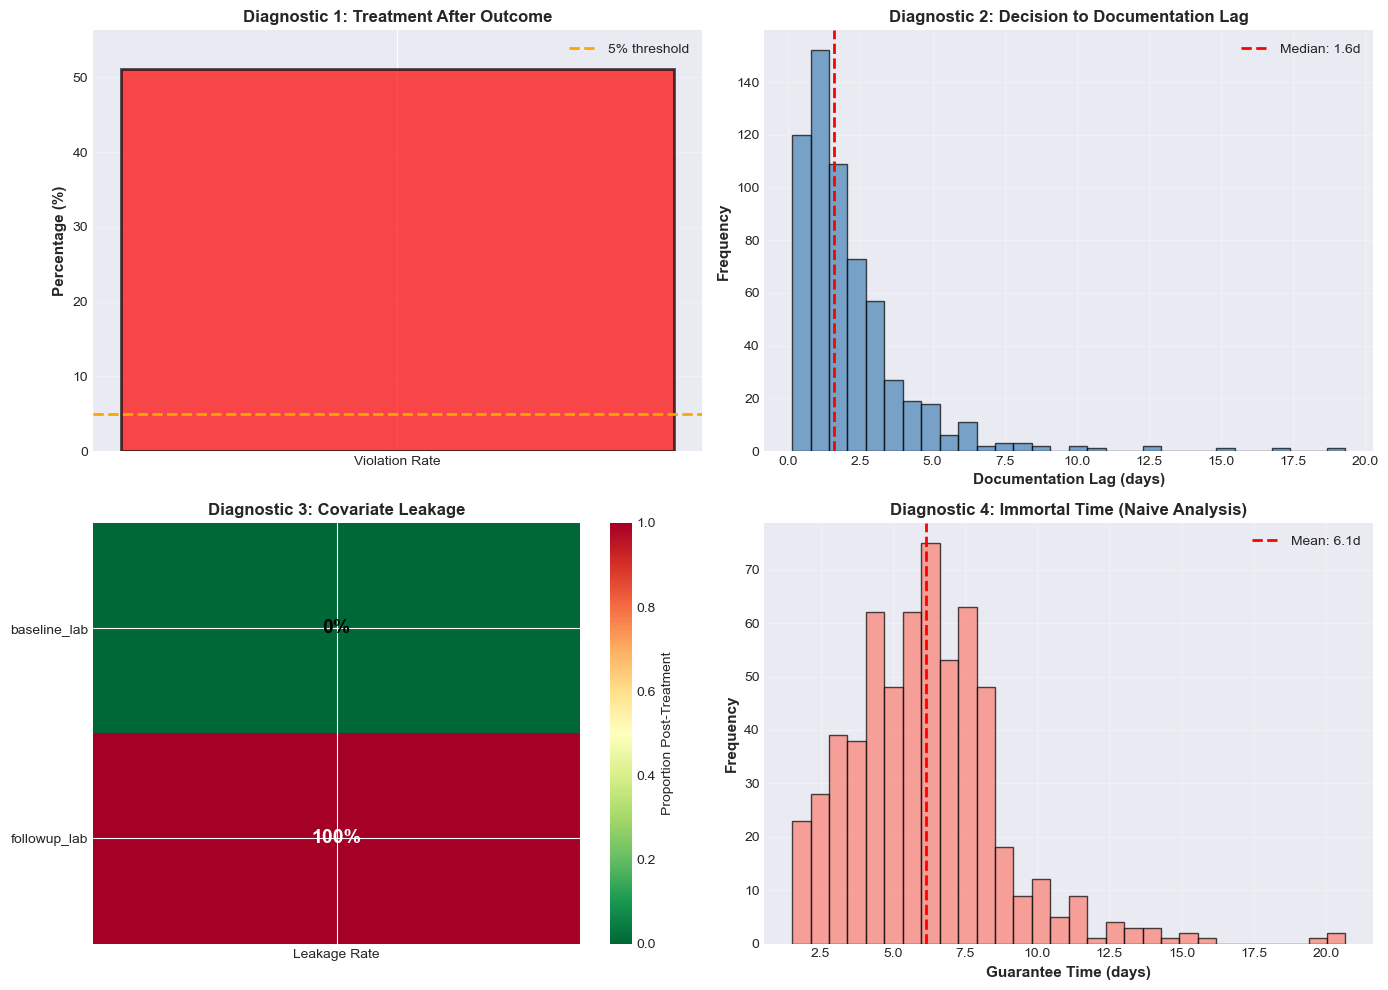

In [15]:
def plot_diagnostic_dashboard(diag_results):
    """
    Create a 4-panel diagnostic dashboard.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Panel 1: Temporal violations
    ax = axes[0, 0]
    violation_rate = diag_results['temporal_violations']['rate']
    colors = ['green' if violation_rate < 0.05 else 'red']
    ax.bar(['Violation Rate'], [violation_rate * 100], color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.axhline(5, color='orange', linestyle='--', linewidth=2, label='5% threshold')
    ax.set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    ax.set_title('Diagnostic 1: Treatment After Outcome', fontsize=12, fontweight='bold')
    ax.set_ylim([0, max(10, violation_rate * 110)])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Panel 2: Documentation lag distribution
    ax = axes[0, 1]
    doc_lag = diag_results['documentation_lag']['distribution']
    ax.hist(doc_lag, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(diag_results['documentation_lag']['median'], color='red', linestyle='--', 
              linewidth=2, label=f"Median: {diag_results['documentation_lag']['median']:.1f}d")
    ax.set_xlabel('Documentation Lag (days)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Diagnostic 2: Decision to Documentation Lag', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Panel 3: Covariate leakage heatmap
    ax = axes[1, 0]
    leakage_data = [
        [diag_results['covariate_leakage']['baseline_lab_leakage']],
        [diag_results['covariate_leakage']['followup_lab_leakage']]
    ]
    im = ax.imshow(leakage_data, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['baseline_lab', 'followup_lab'])
    ax.set_xticks([0])
    ax.set_xticklabels(['Leakage Rate'])
    ax.set_title('Diagnostic 3: Covariate Leakage', fontsize=12, fontweight='bold')
    
    # Add text annotations
    for i in range(len(leakage_data)):
        text = ax.text(0, i, f"{leakage_data[i][0]:.0%}", ha="center", va="center", 
                      color="white" if leakage_data[i][0] > 0.5 else "black", fontweight='bold', fontsize=14)
    
    plt.colorbar(im, ax=ax, label='Proportion Post-Treatment')
    
    # Panel 4: Guarantee time (immortal time)
    ax = axes[1, 1]
    guarantee = diag_results['guarantee_time']['distribution']
    ax.hist(guarantee, bins=30, color='salmon', alpha=0.7, edgecolor='black')
    ax.axvline(diag_results['guarantee_time']['mean'], color='red', linestyle='--', 
              linewidth=2, label=f"Mean: {diag_results['guarantee_time']['mean']:.1f}d")
    ax.set_xlabel('Guarantee Time (days)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Diagnostic 4: Immortal Time (Naive Analysis)', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

fig = plot_diagnostic_dashboard(diag_results)
plt.show()

### 2.1 Traffic Light Summary Table

Quick visual summary of data quality checks.

In [17]:
def create_traffic_light_summary(diag_results):
    """
    Create traffic light summary table for diagnostics.
    """
    def get_status(metric, threshold_green, threshold_yellow, lower_is_better=True):
        if lower_is_better:
            if metric <= threshold_green:
                return '🟢 PASS'
            elif metric <= threshold_yellow:
                return '🟡 CAUTION'
            else:
                return '🔴 FAIL'
        else:
            if metric >= threshold_green:
                return '🟢 PASS'
            elif metric >= threshold_yellow:
                return '🟡 CAUTION'
            else:
                return '🔴 FAIL'
    
    summary_data = [
        {
            'Diagnostic': 'Treatment after outcome',
            'Metric': f"{diag_results['temporal_violations']['rate']:.1%}",
            'Threshold': '<5% (green), <10% (yellow)',
            'Status': get_status(diag_results['temporal_violations']['rate'], 0.05, 0.10, lower_is_better=True)
        },
        {
            'Diagnostic': 'Documentation lag (p95)',
            'Metric': f"{diag_results['documentation_lag']['p95']:.1f} days",
            'Threshold': '<14d (green), <30d (yellow)',
            'Status': get_status(diag_results['documentation_lag']['p95'], 14, 30, lower_is_better=True)
        },
        {
            'Diagnostic': 'Covariate leakage',
            'Metric': f"{diag_results['covariate_leakage']['followup_lab_leakage']:.0%}",
            'Threshold': '<10% (green), <25% (yellow)',
            'Status': get_status(diag_results['covariate_leakage']['followup_lab_leakage'], 0.10, 0.25, lower_is_better=True)
        },
        {
            'Diagnostic': 'Mean guarantee time',
            'Metric': f"{diag_results['guarantee_time']['mean']:.1f} days",
            'Threshold': '<7d (green), <14d (yellow)',
            'Status': get_status(diag_results['guarantee_time']['mean'], 7, 14, lower_is_better=True)
        }
    ]
    
    summary_df = pd.DataFrame(summary_data)
    return summary_df

traffic_light = create_traffic_light_summary(diag_results)
print("\n" + "=" * 90)
print("TRAFFIC LIGHT SUMMARY: Time-Zero Diagnostics")
print("=" * 90)
print(traffic_light.to_string(index=False))
print("=" * 90)


TRAFFIC LIGHT SUMMARY: Time-Zero Diagnostics
             Diagnostic   Metric                   Threshold Status
Treatment after outcome    51.1%  <5% (green), <10% (yellow) 🔴 FAIL
Documentation lag (p95) 5.5 days <14d (green), <30d (yellow) 🟢 PASS
      Covariate leakage     100% <10% (green), <25% (yellow) 🔴 FAIL
    Mean guarantee time 6.1 days  <7d (green), <14d (yellow) 🟢 PASS


## 3. Two Fixes and Their Estimand Shifts

We now demonstrate two common fixes:

1. **Landmark Analysis**: Restrict to patients who survive event-free to a landmark time
2. **Time-Varying Exposure**: Model treatment as a time-varying covariate

**Critical point:** Each fix changes the estimand (the question we're answering).

### 3.1 Fix 1: Landmark Analysis

**Estimand:** "Among patients who survive event-free to day L, what is the treatment effect?"

**Population:** Survivors to landmark

**Key assumption:** Treatment decision should be finalized by landmark

In [19]:
def landmark_analysis(df, landmark_day=30):
    """
    Perform landmark analysis.
    
    Args:
        df: cohort dataframe
        landmark_day: landmark time (days from encounter)
    
    Returns:
        Landmark dataset and results
    """
    # Create time from encounter
    df_landmark = df.copy()
    df_landmark['time_from_encounter'] = df_landmark['t_outcome'] - df_landmark['t_encounter']
    
    # Restrict to patients who:
    # 1. Survive event-free to landmark
    # 2. Have follow-up time >= landmark
    df_landmark = df_landmark[
        (df_landmark['time_from_encounter'] >= landmark_day) | 
        ((df_landmark['time_from_encounter'] < landmark_day) & (df_landmark['event'] == 0))
    ].copy()
    
    # Further restrict: must not have event before landmark
    df_landmark = df_landmark[
        (df_landmark['event'] == 0) | 
        (df_landmark['time_from_encounter'] >= landmark_day)
    ].copy()
    
    # Redefine time and event
    df_landmark['time'] = df_landmark['time_from_encounter'] - landmark_day
    df_landmark['time'] = df_landmark['time'].clip(lower=0.01)
    df_landmark['event_landmark'] = (
        (df_landmark['event'] == 1) & 
        (df_landmark['time_from_encounter'] >= landmark_day)
    ).astype(int)
    
    return df_landmark

# Perform landmark analysis at day 30
landmark_day = 30
df_landmark = landmark_analysis(df, landmark_day=landmark_day)

print(f"Original cohort size: {len(df)}")
print(f"Landmark cohort size (day {landmark_day}): {len(df_landmark)}")
print(f"Exclusion rate: {(1 - len(df_landmark)/len(df)):.1%}")
print(f"Events in landmark cohort: {df_landmark['event_landmark'].sum()}")

Original cohort size: 1000
Landmark cohort size (day 30): 230
Exclusion rate: 77.0%
Events in landmark cohort: 230


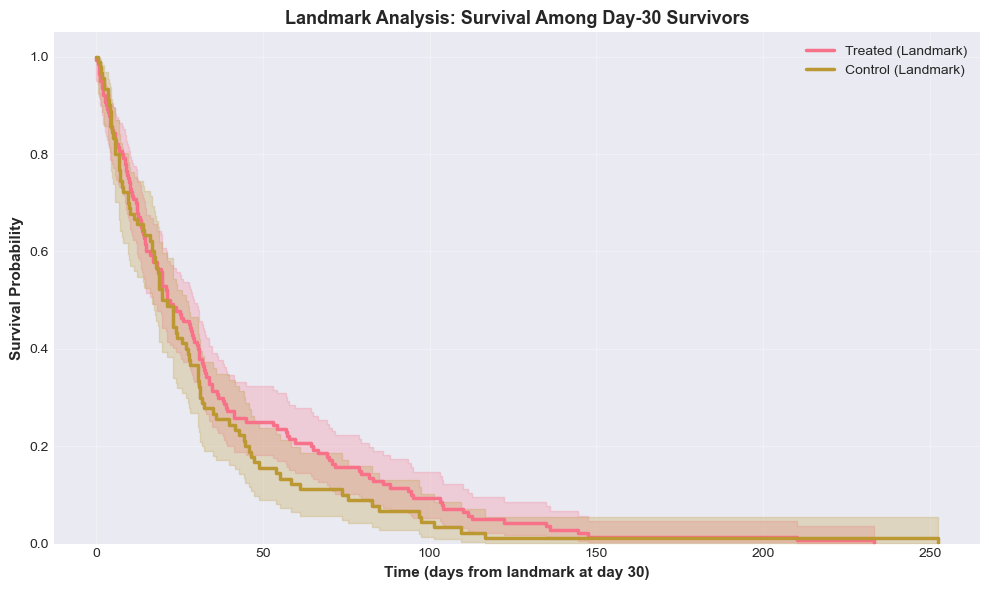

In [21]:
def plot_landmark_survival(df, df_landmark, landmark_day):
    """
    Plot survival curves for landmark analysis.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Fit KM for landmark cohort
    kmf_treated_lm = KaplanMeierFitter()
    kmf_control_lm = KaplanMeierFitter()
    
    treated_lm = df_landmark[df_landmark['treated'] == 1]
    control_lm = df_landmark[df_landmark['treated'] == 0]
    
    kmf_treated_lm.fit(treated_lm['time'], treated_lm['event_landmark'], label='Treated (Landmark)')
    kmf_control_lm.fit(control_lm['time'], control_lm['event_landmark'], label='Control (Landmark)')
    
    kmf_treated_lm.plot_survival_function(ax=ax, ci_show=True, linewidth=2.5, linestyle='-')
    kmf_control_lm.plot_survival_function(ax=ax, ci_show=True, linewidth=2.5, linestyle='-')
    
    ax.set_xlabel(f'Time (days from landmark at day {landmark_day})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Survival Probability', fontsize=11, fontweight='bold')
    ax.set_title(f'Landmark Analysis: Survival Among Day-{landmark_day} Survivors', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    
    plt.tight_layout()
    return fig

fig = plot_landmark_survival(df, df_landmark, landmark_day)
plt.show()

### 3.2 Fix 2: Time-Varying Exposure

**Estimand:** "What is the instantaneous hazard ratio associated with treatment exposure?"

**Population:** All patients from encounter

**Key assumption:** No unmeasured time-varying confounding

In [23]:
def prepare_time_varying_data(df):
    """
    Prepare data for time-varying Cox model.
    
    Each patient gets two rows:
    - Before documentation: treated = 0
    - After documentation: treated = 1 (only for treated patients)
    """
    tv_records = []
    
    for _, row in df.iterrows():
        # Reference time is encounter
        t_start_ref = row['t_encounter']
        t_end_ref = row['t_outcome']
        
        if row['treated'] == 1 and not np.isnan(row['t_documentation']):
            # Split into two intervals
            t_doc_rel = row['t_documentation'] - t_start_ref
            t_end_rel = t_end_ref - t_start_ref
            
            # Interval 1: Before documentation (unexposed)
            if t_doc_rel > 0:
                tv_records.append({
                    'patient_id': row['patient_id'],
                    'start': 0,
                    'stop': t_doc_rel,
                    'event': 0,  # No event in this interval
                    'treated_tv': 0,  # Not yet treated
                    'severity': row['severity'],
                    'baseline_lab': row['baseline_lab']
                })
            
            # Interval 2: After documentation (exposed)
            tv_records.append({
                'patient_id': row['patient_id'],
                'start': max(0, t_doc_rel),
                'stop': t_end_rel,
                'event': row['event'],
                'treated_tv': 1,  # Now treated
                'severity': row['severity'],
                'baseline_lab': row['baseline_lab']
            })
        else:
            # Control patients: single interval, always unexposed
            t_end_rel = t_end_ref - t_start_ref
            tv_records.append({
                'patient_id': row['patient_id'],
                'start': 0,
                'stop': t_end_rel,
                'event': row['event'],
                'treated_tv': 0,
                'severity': row['severity'],
                'baseline_lab': row['baseline_lab']
            })
    
    df_tv = pd.DataFrame(tv_records)
    # Clean up: remove intervals with zero duration
    df_tv = df_tv[df_tv['stop'] > df_tv['start']]
    
    return df_tv

df_tv = prepare_time_varying_data(df)
print(f"Time-varying dataset: {len(df_tv)} intervals from {df_tv['patient_id'].nunique()} patients")
print(f"\nSample of time-varying data:")
print(df_tv.head(10))

Time-varying dataset: 1172 intervals from 874 patients

Sample of time-varying data:
    patient_id     start       stop  event  treated_tv  severity  baseline_lab
0          0.0  0.000000   8.470588    0.0           0  2.393679     15.234340
2          1.0  0.000000  47.654320    1.0           0  1.494465     12.350344
4          3.0  0.000000   7.296697    0.0           0  1.382302     13.387692
5          3.0  7.296697  47.009439    1.0           1  1.382302     13.387692
6          4.0  0.000000   4.460541    0.0           0  4.649714     19.539287
7          4.0  4.460541  16.174526    1.0           1  4.649714     19.539287
9          6.0  0.000000  13.077977    1.0           0  1.131078     11.263715
10         7.0  0.000000   2.329143    0.0           0  2.469814     16.562886
11         7.0  2.329143  20.265457    1.0           1  2.469814     16.562886
12         8.0  0.000000   6.071308    0.0           0  1.998960     15.989291


In [34]:
def fit_time_varying_cox(df_tv):
    """
    Fit Cox model with time-varying treatment.
    """
    # Prepare data for lifelines
    df_cox = df_tv.copy()
    
    # Fit Cox model - use entry_col for left truncation/time-varying
    cph = CoxPHFitter()
    cph.fit(df_cox, 
            duration_col='stop', 
            event_col='event', 
            entry_col='start',  # CORRECT parameter name
            formula='treated_tv + severity',
            cluster_col='patient_id')
    
    return cph

# Fit models
print("Fitting time-varying Cox model...")
cph_tv = fit_time_varying_cox(df_tv)
print("\nTime-Varying Cox Model Results:")
print(cph_tv.summary[['coef', 'exp(coef)', 'se(coef)', 'p']])

Fitting time-varying Cox model...

Time-Varying Cox Model Results:
                coef  exp(coef)  se(coef)         p
covariate                                          
treated_tv -0.064207   0.937811  0.091168  0.481261
severity    0.139205   1.149360  0.037965  0.000246


### 3.3 Comparative Results Table

**Key insight:** Each approach answers a different question with different populations and assumptions.

In [36]:
def create_comparative_results_table(df, datasets, df_landmark, cph_tv, landmark_day):
    """
    Create comprehensive comparison table.
    """
    results = []
    
    # TRUE EFFECT (from simulation)
    true_hr = 0.6
    
    # 1. NAIVE (Encounter-anchored)
    df_naive = datasets['Naive (Encounter)']
    cph_naive = CoxPHFitter()
    cph_naive.fit(df_naive[['time', 'event', 'treated', 'severity']], 
                  duration_col='time', event_col='event', formula='treated + severity')
    hr_naive = cph_naive.summary.loc['treated', 'exp(coef)']
    
    results.append({
        'Approach': 'Naive (Encounter)',
        'Estimand': 'Treatment effect from encounter',
        'Population': f'All {len(df_naive)} patients',
        'Key Assumptions': 'Treatment assigned at encounter (WRONG)',
        'Hazard Ratio': f"{hr_naive:.2f}",
        'Bias vs Truth': f"{hr_naive - true_hr:+.2f}",
        'Direction': '⬇️ Underestimated' if hr_naive < true_hr else '⬆️ Overestimated'
    })
    
    # 2. DECISION-ANCHORED
    df_decision = datasets['Decision-anchored']
    cph_decision = CoxPHFitter()
    cph_decision.fit(df_decision[['time', 'event', 'treated', 'severity']], 
                     duration_col='time', event_col='event', formula='treated + severity')
    hr_decision = cph_decision.summary.loc['treated', 'exp(coef)']
    
    results.append({
        'Approach': 'Decision-anchored',
        'Estimand': 'Treatment effect from decision',
        'Population': f'All {len(df_decision)} patients',
        'Key Assumptions': 'No confounding at decision time',
        'Hazard Ratio': f"{hr_decision:.2f}",
        'Bias vs Truth': f"{hr_decision - true_hr:+.2f}",
        'Direction': '⬇️ Underestimated' if hr_decision < true_hr else '⬆️ Overestimated'
    })
    
    # 3. LANDMARK
    cph_landmark = CoxPHFitter()
    cph_landmark.fit(df_landmark[['time', 'event_landmark', 'treated', 'severity']], 
                     duration_col='time', event_col='event_landmark', formula='treated + severity')
    hr_landmark = cph_landmark.summary.loc['treated', 'exp(coef)']
    
    results.append({
        'Approach': f'Landmark (day {landmark_day})',
        'Estimand': f'Effect among day-{landmark_day} survivors',
        'Population': f'{len(df_landmark)} survivors ({len(df_landmark)/len(df):.0%} of original)',
        'Key Assumptions': 'Treatment fixed by landmark; no early events',
        'Hazard Ratio': f"{hr_landmark:.2f}",
        'Bias vs Truth': f"{hr_landmark - true_hr:+.2f}",
        'Direction': '⬇️ Underestimated' if hr_landmark < true_hr else '⬆️ Overestimated'
    })
    
    # 4. TIME-VARYING
    hr_tv = cph_tv.summary.loc['treated_tv', 'exp(coef)']
    
    results.append({
        'Approach': 'Time-varying Cox',
        'Estimand': 'Instantaneous treatment exposure effect',
        'Population': f'All {df["patient_id"].nunique()} patients (dynamic exposure)',
        'Key Assumptions': 'No unmeasured time-varying confounding',
        'Hazard Ratio': f"{hr_tv:.2f}",
        'Bias vs Truth': f"{hr_tv - true_hr:+.2f}",
        'Direction': '⬇️ Underestimated' if hr_tv < true_hr else '⬆️ Overestimated'
    })
    
    # 5. TRUTH (for reference)
    results.append({
        'Approach': 'TRUTH (Onset-aligned)',
        'Estimand': 'Causal effect from disease onset',
        'Population': f'All {len(df)} patients (from onset)',
        'Key Assumptions': 'Simulated ground truth',
        'Hazard Ratio': f"{true_hr:.2f}",
        'Bias vs Truth': '—',
        'Direction': 'Reference'
    })
    
    return pd.DataFrame(results)

results_table = create_comparative_results_table(df, datasets, df_landmark, cph_tv, landmark_day)

print("\n" + "=" * 120)
print("COMPARATIVE RESULTS: How Time-Zero Choice Changes the Estimand")
print("=" * 120)
print(results_table.to_string(index=False))
print("=" * 120)


COMPARATIVE RESULTS: How Time-Zero Choice Changes the Estimand
             Approach                                Estimand                           Population                              Key Assumptions Hazard Ratio Bias vs Truth        Direction
    Naive (Encounter)         Treatment effect from encounter                    All 1000 patients      Treatment assigned at encounter (WRONG)         0.68         +0.08 ⬆️ Overestimated
    Decision-anchored          Treatment effect from decision                    All 1000 patients              No confounding at decision time         0.68         +0.08 ⬆️ Overestimated
    Landmark (day 30)           Effect among day-30 survivors      230 survivors (23% of original) Treatment fixed by landmark; no early events         0.66         +0.06 ⬆️ Overestimated
     Time-varying Cox Instantaneous treatment exposure effect All 1000 patients (dynamic exposure)       No unmeasured time-varying confounding         0.94         +0.34 ⬆️ Overestima

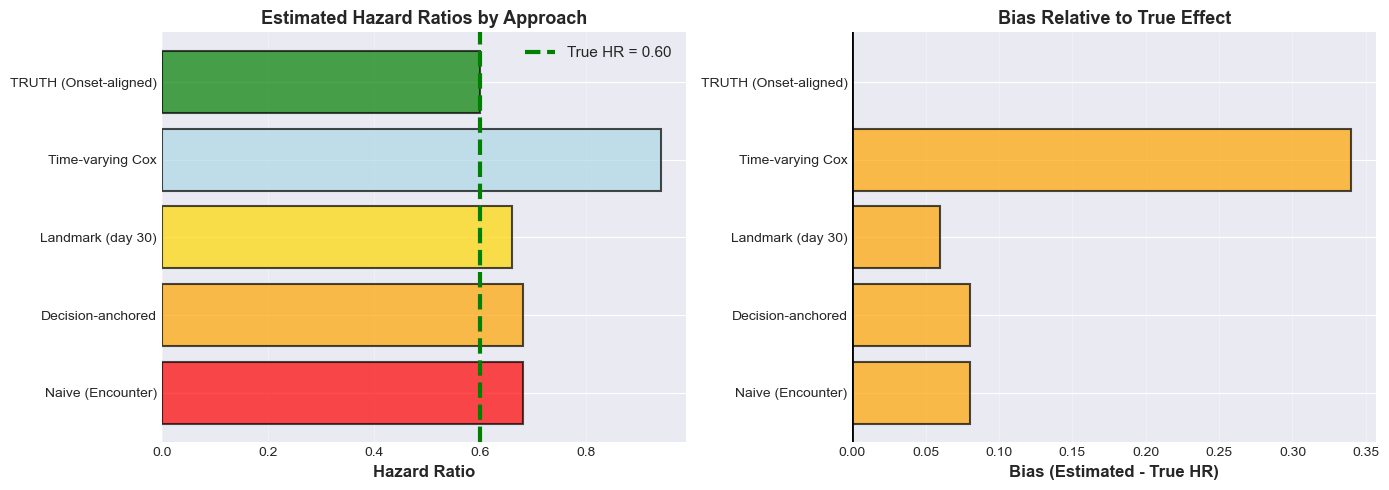

In [38]:
def plot_estimand_comparison(results_table):
    """
    Visualize hazard ratios and bias across approaches.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Extract HRs
    approaches = results_table['Approach'].values
    hrs = results_table['Hazard Ratio'].apply(lambda x: float(x) if x != '—' else np.nan).values
    
    # Panel 1: Hazard ratios
    colors = ['red', 'orange', 'gold', 'lightblue', 'green']
    bars = ax1.barh(approaches, hrs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax1.axvline(0.6, color='green', linestyle='--', linewidth=3, label='True HR = 0.60')
    ax1.set_xlabel('Hazard Ratio', fontsize=12, fontweight='bold')
    ax1.set_title('Estimated Hazard Ratios by Approach', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Panel 2: Bias
    bias = []
    for b in results_table['Bias vs Truth'].values:
        if b == '—':
            bias.append(0)
        else:
            bias.append(float(b))
    
    colors_bias = ['red' if b < -0.05 else 'green' if abs(b) < 0.05 else 'orange' for b in bias]
    bars = ax2.barh(approaches, bias, color=colors_bias, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax2.axvline(0, color='black', linestyle='-', linewidth=2)
    ax2.set_xlabel('Bias (Estimated - True HR)', fontsize=12, fontweight='bold')
    ax2.set_title('Bias Relative to True Effect', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    return fig

fig = plot_estimand_comparison(results_table)
plt.show()

## 4. The Unfixable Problem: When Onset is Severely Delayed

**Key lesson:** Some time-zero problems cannot be fixed with statistical methods.

We simulate a scenario where:
- Onset-to-encounter delay is **long** (median 90 days)
- Delay is **strongly correlated** with severity
- Sicker patients delay care longer (e.g., due to access barriers)

**Result:** Even time-varying exposure cannot recover the onset-aligned effect because the **entry time** is informative about prognosis.

In [40]:
def simulate_severe_delay_cohort(n=1000, seed=43):
    """
    Simulate cohort with severe onset-to-encounter delay correlated with severity.
    """
    np.random.seed(seed)
    
    # Severity
    severity = np.random.gamma(shape=2, scale=1, size=n)
    
    # T_onset = 0
    t_onset = np.zeros(n)
    
    # SEVERE DELAY: Much longer delays, strongly correlated with severity
    # Sicker patients delay much longer
    delay_mean = 60 + 90 * (severity / severity.max())  # Mean delay 60-150 days
    t_encounter = t_onset + np.random.exponential(delay_mean)
    
    # Decision shortly after encounter
    t_decision = t_encounter + np.random.uniform(1, 7, size=n)
    
    # Treatment (depends on severity)
    treatment_prob = 1 / (1 + np.exp(-(-1 + 0.8 * severity)))
    treated = np.random.binomial(1, treatment_prob)
    
    # Documentation
    doc_lag = np.random.lognormal(mean=0.5, sigma=0.8, size=n)
    t_documentation = np.where(treated == 1, t_decision + doc_lag, np.nan)
    
    # Outcome (from onset)
    baseline_hazard = 0.015  # Slightly lower for longer follow-up
    hazard = baseline_hazard * np.exp(0.5 * severity - 0.51 * treated)
    t_outcome_from_onset = np.random.exponential(1 / hazard)
    
    # Many will have outcome BEFORE encounter (selection bias)
    admin_censor = 365
    event = (t_outcome_from_onset < admin_censor).astype(int)
    t_outcome = np.minimum(t_outcome_from_onset, admin_censor)
    
    # Baseline lab
    baseline_lab = 10 + 2 * severity + np.random.normal(0, 1, n)
    
    df_severe = pd.DataFrame({
        'patient_id': range(n),
        'severity': severity,
        't_onset': t_onset,
        't_encounter': t_encounter,
        't_decision': t_decision,
        't_documentation': t_documentation,
        'treated': treated,
        't_outcome': t_outcome,
        'event': event,
        'baseline_lab': baseline_lab
    })
    
    return df_severe

# Generate severe delay cohort
df_severe = simulate_severe_delay_cohort(n=1000)

# Key statistics
delay_to_encounter = df_severe['t_encounter'] - df_severe['t_onset']
early_death = (df_severe['t_outcome'] < df_severe['t_encounter']).sum()

print("="*70)
print("SEVERE DELAY SCENARIO: The Unfixable Problem")
print("="*70)
print(f"Median onset-to-encounter delay: {delay_to_encounter.median():.1f} days")
print(f"Mean delay: {delay_to_encounter.mean():.1f} days")
print(f"Patients with outcome BEFORE first encounter: {early_death}/{len(df_severe)} ({early_death/len(df_severe):.1%})")
print(f"Correlation (severity, delay): {np.corrcoef(df_severe['severity'], delay_to_encounter)[0,1]:.2f}")
print("\n⚠️  WARNING: This creates severe selection bias — only survivors enter the cohort!")

SEVERE DELAY SCENARIO: The Unfixable Problem
Median onset-to-encounter delay: 58.3 days
Mean delay: 86.0 days
Patients with outcome BEFORE first encounter: 691/1000 (69.1%)
Correlation (severity, delay): 0.16

⚠️  WARNING: This creates severe selection bias — only survivors enter the cohort!


In [44]:
def analyze_severe_delay_impact(df_severe):
    """
    Show that even time-varying Cox cannot fix severe onset-delay problems.
    """
    # Only include patients who survive to encounter
    df_observed = df_severe[df_severe['t_outcome'] >= df_severe['t_encounter']].copy()
    
    print(f"\nObserved cohort (survived to encounter): {len(df_observed)}/{len(df_severe)} ({len(df_observed)/len(df_severe):.1%})")
    
    # Prepare time-varying data
    df_tv_severe = prepare_time_varying_data(df_observed)
    
    # Fit time-varying Cox
    cph_tv_severe = CoxPHFitter()
    cph_tv_severe.fit(df_tv_severe, duration_col='stop', event_col='event',
                     entry_col='start',  # CHANGED: entry_col instead of start_col
                     formula='treated_tv + severity',
                     cluster_col='patient_id')
    
    hr_tv_severe = cph_tv_severe.summary.loc['treated_tv', 'exp(coef)']
    
    # For comparison, fit on original (no severe delay) cohort
    df_tv_original = prepare_time_varying_data(df[df['t_outcome'] >= df['t_encounter']])
    cph_tv_original = CoxPHFitter()
    cph_tv_original.fit(df_tv_original, duration_col='stop', event_col='event',
                       entry_col='start',  # CHANGED: entry_col instead of start_col
                       formula='treated_tv + severity',
                       cluster_col='patient_id')
    hr_tv_original = cph_tv_original.summary.loc['treated_tv', 'exp(coef)']
    
    print("\n" + "="*70)
    print("TIME-VARYING COX: Does it fix the severe delay problem?")
    print("="*70)
    print(f"True HR (from simulation): 0.60")
    print(f"Estimated HR (original cohort, mild delay): {hr_tv_original:.2f}")
    print(f"Estimated HR (severe delay cohort): {hr_tv_severe:.2f}")
    print(f"\nBias in severe delay scenario: {hr_tv_severe - 0.6:.2f}")
    print("\n⚠️  CONCLUSION: Time-varying Cox CANNOT recover onset-aligned effect")
    print("   when entry time is informative (left truncation + selection bias)")
    
    return cph_tv_severe, cph_tv_original, hr_tv_severe, hr_tv_original

cph_tv_severe, cph_tv_original, hr_severe, hr_original = analyze_severe_delay_impact(df_severe)


Observed cohort (survived to encounter): 309/1000 (30.9%)

TIME-VARYING COX: Does it fix the severe delay problem?
True HR (from simulation): 0.60
Estimated HR (original cohort, mild delay): 0.80
Estimated HR (severe delay cohort): 0.80

Bias in severe delay scenario: 0.20

⚠️  CONCLUSION: Time-varying Cox CANNOT recover onset-aligned effect
   when entry time is informative (left truncation + selection bias)


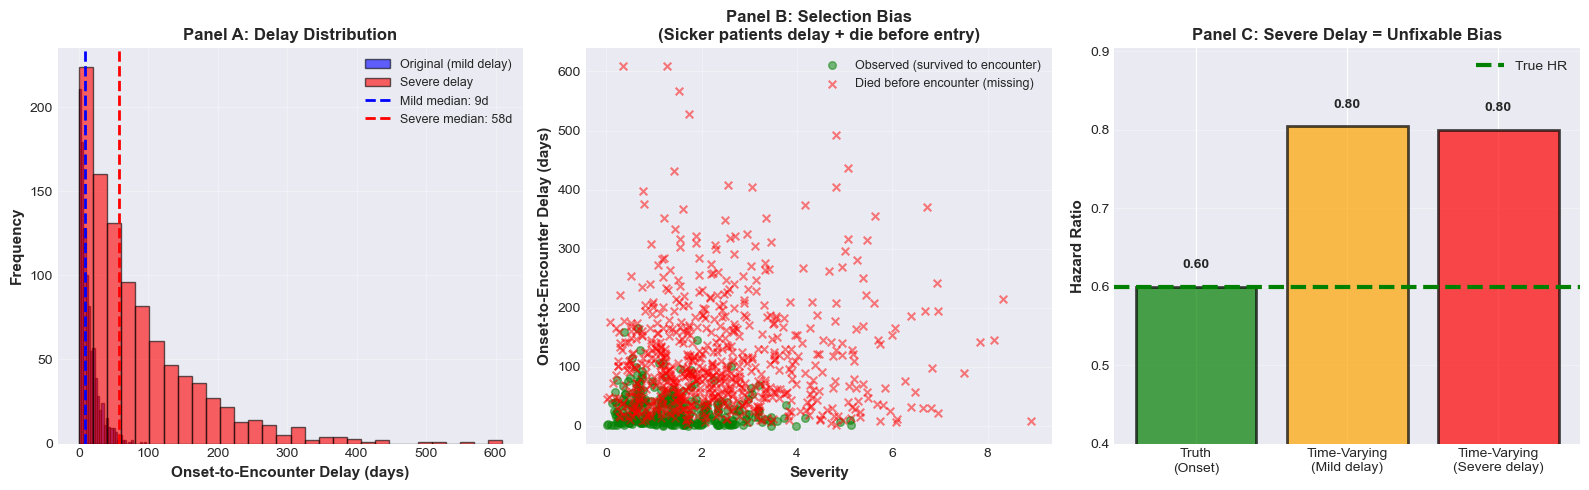

In [46]:
def plot_unfixable_problem(df, df_severe):
    """
    Visualize why severe delay creates unfixable bias.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Panel 1: Delay distribution comparison
    ax = axes[0]
    delay_mild = df['t_encounter'] - df['t_onset']
    delay_severe = df_severe['t_encounter'] - df_severe['t_onset']
    
    ax.hist(delay_mild, bins=30, alpha=0.6, label='Original (mild delay)', color='blue', edgecolor='black')
    ax.hist(delay_severe, bins=30, alpha=0.6, label='Severe delay', color='red', edgecolor='black')
    ax.axvline(delay_mild.median(), color='blue', linestyle='--', linewidth=2, label=f'Mild median: {delay_mild.median():.0f}d')
    ax.axvline(delay_severe.median(), color='red', linestyle='--', linewidth=2, label=f'Severe median: {delay_severe.median():.0f}d')
    ax.set_xlabel('Onset-to-Encounter Delay (days)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title('Panel A: Delay Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Panel 2: Selection bias visualization
    ax = axes[1]
    
    # Show correlation between severity and delay
    delay_severe_vals = df_severe['t_encounter'] - df_severe['t_onset']
    died_before_encounter = df_severe['t_outcome'] < df_severe['t_encounter']
    
    ax.scatter(df_severe.loc[~died_before_encounter, 'severity'], 
              delay_severe_vals[~died_before_encounter],
              alpha=0.5, s=30, label='Observed (survived to encounter)', color='green')
    ax.scatter(df_severe.loc[died_before_encounter, 'severity'], 
              delay_severe_vals[died_before_encounter],
              alpha=0.5, s=30, marker='x', label='Died before encounter (missing)', color='red')
    
    ax.set_xlabel('Severity', fontsize=11, fontweight='bold')
    ax.set_ylabel('Onset-to-Encounter Delay (days)', fontsize=11, fontweight='bold')
    ax.set_title('Panel B: Selection Bias\n(Sicker patients delay + die before entry)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Panel 3: Hazard ratio comparison
    ax = axes[2]
    approaches_unfixable = ['Truth\n(Onset)', 'Time-Varying\n(Mild delay)', 'Time-Varying\n(Severe delay)']
    hrs_unfixable = [0.60, hr_original, hr_severe]
    colors_unfixable = ['green', 'orange', 'red']
    
    bars = ax.bar(approaches_unfixable, hrs_unfixable, color=colors_unfixable, alpha=0.7, edgecolor='black', linewidth=2)
    ax.axhline(0.6, color='green', linestyle='--', linewidth=3, label='True HR')
    ax.set_ylabel('Hazard Ratio', fontsize=11, fontweight='bold')
    ax.set_title('Panel C: Severe Delay = Unfixable Bias', fontsize=12, fontweight='bold')
    ax.set_ylim([0.4, max(hrs_unfixable) + 0.1])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for i, (bar, hr) in enumerate(zip(bars, hrs_unfixable)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
               f'{hr:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    return fig

fig = plot_unfixable_problem(df, df_severe)
plt.show()

### 4.1 DAG: Unobserved Confounding Through Entry Time

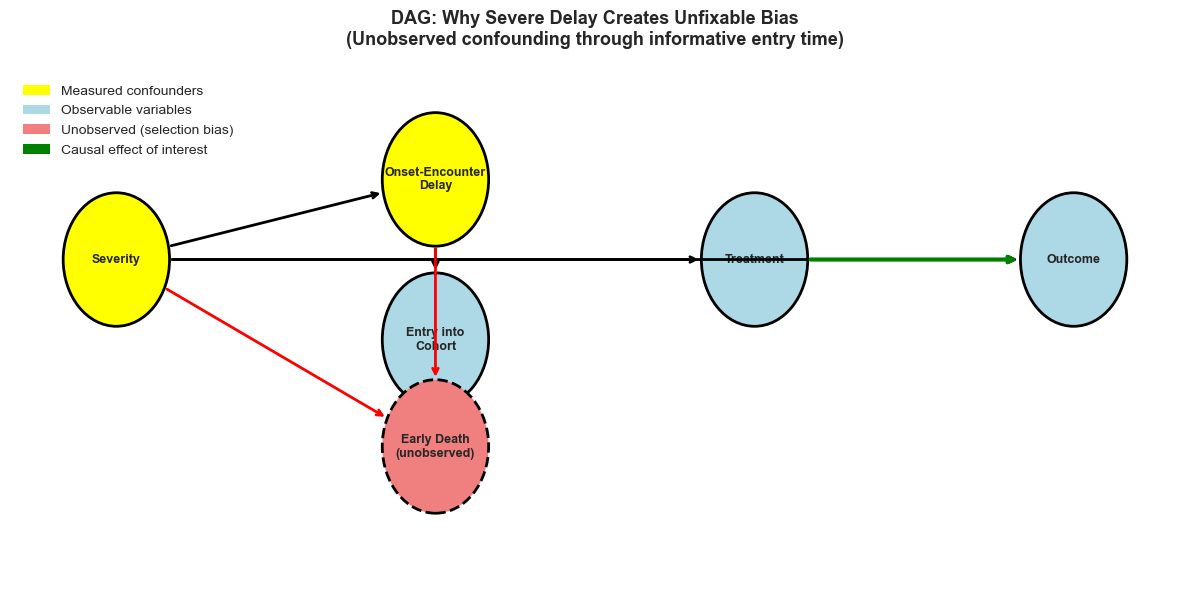

In [48]:
def create_dag_unfixable():
    """
    Create DAG showing unobserved confounding path.
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Node positions
    nodes = {
        'Severity': (0, 0.5),
        'Onset-Encounter\nDelay': (1.5, 0.8),
        'Treatment': (3, 0.5),
        'Outcome': (4.5, 0.5),
        'Entry into\nCohort': (1.5, 0.2),
        'Early Death\n(unobserved)': (1.5, -0.2)
    }
    
    # Draw nodes
    for name, (x, y) in nodes.items():
        if 'unobserved' in name:
            color = 'lightcoral'
            style = 'dashed'
        elif name in ['Severity', 'Onset-Encounter\nDelay']:
            color = 'yellow'
            style = 'solid'
        else:
            color = 'lightblue'
            style = 'solid'
        
        circle = plt.Circle((x, y), 0.25, color=color, ec='black', linewidth=2, linestyle=style)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', fontsize=9, fontweight='bold')
    
    # Draw arrows
    arrows = [
        ('Severity', 'Onset-Encounter\nDelay', 'black', 2),
        ('Severity', 'Treatment', 'black', 2),
        ('Severity', 'Outcome', 'black', 2),
        ('Onset-Encounter\nDelay', 'Entry into\nCohort', 'black', 2),
        ('Onset-Encounter\nDelay', 'Early Death\n(unobserved)', 'red', 2),
        ('Treatment', 'Outcome', 'green', 3),
        ('Severity', 'Early Death\n(unobserved)', 'red', 2)
    ]
    
    for start, end, color, width in arrows:
        x1, y1 = nodes[start]
        x2, y2 = nodes[end]
        
        # Adjust for node radius
        dx = x2 - x1
        dy = y2 - y1
        dist = np.sqrt(dx**2 + dy**2)
        
        start_x = x1 + 0.25 * dx / dist
        start_y = y1 + 0.25 * dy / dist
        end_x = x2 - 0.25 * dx / dist
        end_y = y2 - 0.25 * dy / dist
        
        ax.annotate('', xy=(end_x, end_y), xytext=(start_x, start_y),
                   arrowprops=dict(arrowstyle='->', lw=width, color=color))
    
    ax.set_xlim(-0.5, 5)
    ax.set_ylim(-0.7, 1.2)
    ax.axis('off')
    ax.set_title('DAG: Why Severe Delay Creates Unfixable Bias\n(Unobserved confounding through informative entry time)', 
                fontsize=13, fontweight='bold', pad=20)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='yellow', label='Measured confounders'),
        Patch(facecolor='lightblue', label='Observable variables'),
        Patch(facecolor='lightcoral', label='Unobserved (selection bias)', linestyle='dashed'),
        Patch(facecolor='green', label='Causal effect of interest')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
    
    plt.tight_layout()
    return fig

fig = create_dag_unfixable()
plt.show()

## 5. Summary and Key Takeaways

### Main Lessons:

1. **Multiple time-zeros exist in EHR data**: onset, encounter, decision, documentation
   - Each choice changes the estimand
   - Naive choices introduce immortal time bias

2. **Diagnostic tools are essential**: 
   - Check for temporal violations
   - Examine documentation lag
   - Detect covariate leakage
   - Quantify guarantee time

3. **Statistical fixes have limits**:
   - Landmark analysis: changes population (excludes early events)
   - Time-varying exposure: requires no unmeasured time-varying confounding
   - Neither recovers onset-aligned effect when entry is severely delayed

4. **Some problems are unfixable**:
   - Severe onset-to-encounter delay + informative entry time
   - Creates selection bias that no statistical method can eliminate
   - **Solution: Prospective design with defined entry criteria**

### Design Principles:

- **Transparency**: Explicitly state your time-zero choice and its implications
- **Diagnostics**: Always run time-zero checks before analysis
- **Estimand clarity**: Define what question you're actually answering
- **Acknowledge limitations**: Some estimands are simply not identifiable from observational EHR data
- **Consider prospective design**: When feasible, prospective cohorts with defined entry reduce bias